## version 1

In [62]:
import torch
import torch.nn as nn

In [63]:
class Model(nn.Module):  ## inheriting nn.Module
  def __init__(self, num_features):
    super().__init__()     # want to use all construction of parent class

    self.linear = nn.Linear(num_features, 1)  #(size of input vector, size of output vector)
    self.sigmoid = nn.Sigmoid()

  def forward(self, features):
    out = self.linear(features)
    out = self.sigmoid(out)

    return out

In [64]:
# create dataset
features = torch.rand(10, 5)
features

tensor([[0.0640, 0.8104, 0.4055, 0.0553, 0.9523],
        [0.8544, 0.5558, 0.6560, 0.6692, 0.3102],
        [0.9827, 0.8334, 0.1043, 0.2423, 0.2506],
        [0.7803, 0.7899, 0.9772, 0.8243, 0.7748],
        [0.5835, 0.6304, 0.9176, 0.4434, 0.2325],
        [0.8225, 0.0582, 0.2147, 0.4025, 0.8578],
        [0.6645, 0.7344, 0.0923, 0.9431, 0.8031],
        [0.2230, 0.7677, 0.7061, 0.3511, 0.8288],
        [0.2451, 0.5202, 0.7008, 0.1730, 0.4815],
        [0.5665, 0.1989, 0.7516, 0.0133, 0.6843]])

In [65]:
features.shape

torch.Size([10, 5])

In [66]:
# create model
model = Model(features.shape[1])

In [67]:
# calling model for forward pass
# model.forward(features)
model(features)

tensor([[0.5765],
        [0.6470],
        [0.6454],
        [0.6530],
        [0.5756],
        [0.7033],
        [0.7186],
        [0.5881],
        [0.5588],
        [0.5934]], grad_fn=<SigmoidBackward0>)

In [68]:
model.linear.weight

Parameter containing:
tensor([[ 0.3514, -0.1566, -0.3193,  0.3926,  0.2821]], requires_grad=True)

In [69]:
# visualize
!pip install torchinfo

In [70]:
from torchinfo import summary
summary(model, input_size = (10, 5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 1]                   6
├─Sigmoid: 1-2                           [10, 1]                   --
Total params: 6
Trainable params: 6
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## version 2

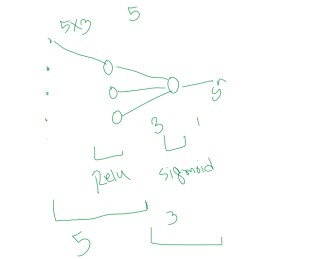

In [71]:
class Model2(nn.Module):
  def __init__(self, num_features):
    super().__init__()

    # layer 1
    self.linear1 = nn.Linear(num_features, 3) # for layer-1, 5 input 3 output
    self.relu = nn.ReLU()

    # layer 2
    self.linear2 = nn.Linear(3,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, features):
    out = self.linear1(features)
    out = self.relu(out)

    out = self.linear2(out)
    out = self.sigmoid(out)

    return out


In [72]:
# create dataset
features = torch.rand(10, 5)
features

tensor([[0.0935, 0.3206, 0.9945, 0.1440, 0.8253],
        [0.6549, 0.9870, 0.3409, 0.4940, 0.0859],
        [0.9129, 0.6843, 0.7006, 0.4362, 0.6304],
        [0.7683, 0.8461, 0.9664, 0.9339, 0.9705],
        [0.4728, 0.6435, 0.8748, 0.6680, 0.9143],
        [0.2228, 0.9035, 0.6393, 0.6601, 0.1870],
        [0.8976, 0.4046, 0.2834, 0.2317, 0.6438],
        [0.8556, 0.6834, 0.6570, 0.6009, 0.2806],
        [0.2146, 0.7963, 0.6413, 0.3641, 0.1351],
        [0.4833, 0.3477, 0.7262, 0.7928, 0.8356]])

In [73]:
model2 = Model2(features.shape[1])

In [74]:
model2(features)

tensor([[0.3666],
        [0.3666],
        [0.3666],
        [0.3666],
        [0.3666],
        [0.3692],
        [0.3666],
        [0.3666],
        [0.3688],
        [0.3666]], grad_fn=<SigmoidBackward0>)

In [75]:
model2.linear1.weight

Parameter containing:
tensor([[-0.3354,  0.0947, -0.2391, -0.0063,  0.0186],
        [-0.3890, -0.1709, -0.1729, -0.1423,  0.0685],
        [ 0.2575, -0.2822,  0.0509, -0.3577, -0.1314]], requires_grad=True)

In [76]:
from torchinfo import summary

summary( model2,input_size = (10,5) )

Layer (type:depth-idx)                   Output Shape              Param #
Model2                                   [10, 1]                   --
├─Linear: 1-1                            [10, 3]                   18
├─ReLU: 1-2                              [10, 3]                   --
├─Linear: 1-3                            [10, 1]                   4
├─Sigmoid: 1-4                           [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## Version-3 (compact version of 2)


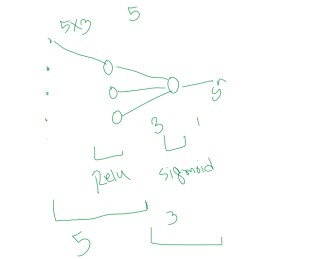

In [77]:
class Model3(nn.Module):
  def __init__(self, num_features):
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(num_features, 3),
        nn.ReLU(),
        nn.Linear(3,1),
        nn.Sigmoid()
    )

  def forward(self, features):
    out = self.network(features)
    return out

In [78]:
model3 = Model3(features.shape[1])

In [79]:
#calling model for forward pass
# model3.forward(features)

model3(features)

tensor([[0.5270],
        [0.5017],
        [0.5008],
        [0.5077],
        [0.5143],
        [0.5219],
        [0.5076],
        [0.4937],
        [0.5230],
        [0.5123]], grad_fn=<SigmoidBackward0>)

In [80]:
from torchinfo import summary

summary( model3,input_size = (10,5) )

Layer (type:depth-idx)                   Output Shape              Param #
Model3                                   [10, 1]                   --
├─Sequential: 1-1                        [10, 1]                   --
│    └─Linear: 2-1                       [10, 3]                   18
│    └─ReLU: 2-2                         [10, 3]                   --
│    └─Linear: 2-3                       [10, 1]                   4
│    └─Sigmoid: 2-4                      [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

# Updated Training Pipeline

In [81]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [82]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [83]:
df.shape

(569, 33)

In [84]:
df.drop(columns=['id', 'Unnamed: 32'], inplace= True)

In [85]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [86]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2)

In [87]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [88]:
# scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# encoder
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [89]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [90]:
len(df.columns)

31

In [91]:
X_train

array([[ 0.3254358 , -1.47162665,  0.25787726, ..., -0.16737777,
        -0.93690317, -0.52320219],
       [-0.37073251, -0.83046804, -0.37646688, ..., -0.25546997,
         0.18956478, -0.34055987],
       [ 1.40963234,  1.23397172,  1.50871425, ...,  2.09785015,
         2.92198852,  1.09496418],
       ...,
       [ 1.23273712,  0.57462422,  1.17244543, ...,  0.3670793 ,
         0.35869919, -0.44747245],
       [-0.73022926, -0.07790244, -0.73722936, ..., -0.74005473,
         0.23718515, -0.07216476],
       [-0.73878871, -1.123764  , -0.71854776, ..., -0.70059191,
        -0.92212444, -0.15569021]])

In [92]:
y_train

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,

In [93]:
type(y_train)

numpy.ndarray

# Numpy Array to tensors

In [94]:
#numpy to tensor and change dtype
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

#numpy to tensor and change dtype
y_train_tensor = torch.tensor(y_train, dtype= torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# y_test_tensor = torch.from_numpy(y_test)

In [95]:
type(X_train_tensor)

torch.Tensor

# Defining the Model

In [96]:
X_train.shape[1]

30

In [97]:
import torch.nn as nn

In [98]:
class MySimpleNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()

    self.linear = nn.Linear(num_features, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, features):
    out = self.linear(features)
    out = self.sigmoid(out)

    return out

In [99]:
learning_rate = 0.1
epochs = 25
loss_function = nn.BCELoss()

In [100]:
model = MySimpleNN(X_train_tensor.shape[1])

In [101]:
model.parameters()

<generator object Module.parameters at 0x7b7a8c5082e0>

In [102]:
X_test_tensor.dtype

torch.float32

In [103]:
model.linear.weight.dtype

torch.float32

In [104]:
# Training Pipeline
# create model
model = MySimpleNN(X_train_tensor.shape[1])

# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
  #forward pass
  y_pred = model(X_train_tensor)

  # Loss calculation
  loss = loss_function(y_pred, y_train_tensor.reshape(-1, 1))

  # Zero gradient
  optimizer.zero_grad()

  # backward pass
  loss.backward()

  # parameter update
  optimizer.step()

  #print loss in each epoch
  print(f" {epoch+1} , Loss = {loss.item()} ")

 1 , Loss = 0.4181717336177826 
 2 , Loss = 0.3719646632671356 
 3 , Loss = 0.3386336863040924 
 4 , Loss = 0.3131975531578064 
 5 , Loss = 0.2929857671260834 
 6 , Loss = 0.2764318585395813 
 7 , Loss = 0.2625529170036316 
 8 , Loss = 0.2506987154483795 
 9 , Loss = 0.24042059481143951 
 10 , Loss = 0.23139816522598267 
 11 , Loss = 0.2233956754207611 
 12 , Loss = 0.2162354588508606 
 13 , Loss = 0.20978064835071564 
 14 , Loss = 0.20392386615276337 
 15 , Loss = 0.1985796093940735 
 16 , Loss = 0.1936785727739334 
 17 , Loss = 0.18916402757167816 
 18 , Loss = 0.18498903512954712 
 19 , Loss = 0.18111422657966614 
 20 , Loss = 0.17750638723373413 
 21 , Loss = 0.1741372048854828 
 22 , Loss = 0.17098236083984375 
 23 , Loss = 0.16802090406417847 
 24 , Loss = 0.16523458063602448 
 25 , Loss = 0.16260747611522675 


In [105]:
# Model evaluation

with torch.no_grad():
  y_pred = model.forward(X_test_tensor)
  y_pred = (y_pred>0.9).float()
  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f"Accuracy = {accuracy.item()}")

Accuracy = 0.5603262782096863
